# Phase 3.2 (Part B) — Production Threshold Selection

Establishes a real production flag threshold on the full 2400-player
held-out test set, using the corrected smooth-sigmoid ensemble scores
from Phase 3.2 Part A (backend/core/inference.py). Reports both the
F1-optimal threshold and a higher-precision alternative, since
tournament admins likely weigh false accusations heavily.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

BACKEND_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from core.inference import load_models, score_players
from core.model import FEATURE_ORDER, get_cleaned_train_test_data

_, _, X_test, y_test = get_cleaned_train_test_data()

models = load_models()

print(f"X_test shape: {X_test.shape}")
print(f"cheater rate in test set: {y_test.mean():.4f}")
print(f"scoring_config: {models['scoring_config']}")

X_test shape: (2400, 11)
cheater rate in test set: 0.1667
scoring_config: {'if_score_p1': -0.12177912083087014, 'if_score_p99': 0.08299678789178934, 'ae_score_p1': 0.015224658520892262, 'ae_score_p99': 1.8832051980495212, 'if_score_median': -0.06934903217390165, 'if_score_scale': 0.05119397718066487, 'ae_score_median': 0.1099381297826767, 'ae_score_scale': 0.4669951348821573, 'ensemble_weight_if': 0.3, 'flag_threshold': 0.5, 'flag_threshold_precision': 0.20903954802259886, 'flag_threshold_recall': 0.6475, 'flag_threshold_f1': 0.3160463697376449, 'flag_threshold_high_precision_alt': 0.9}


## Score all 2400 test players

In [2]:
test_df = pd.DataFrame(X_test, columns=FEATURE_ORDER)
scores = score_players(test_df, models=models)

results = pd.DataFrame({
    "true_label": y_test,
    "ensemble_score": scores["ensemble_score"].values,
})

print(f"results shape: {results.shape}")
print(results.describe())
print()
print("ensemble_score by true label:")
print(results.groupby("true_label")["ensemble_score"].describe())

results shape: (2400, 2)
        true_label  ensemble_score
count  2400.000000     2400.000000
mean      0.166667        0.531007
std       0.372756        0.106092
min       0.000000        0.388632
25%       0.000000        0.458439
50%       0.000000        0.504278
75%       0.000000        0.571290
max       1.000000        0.992021

ensemble_score by true label:
             count      mean      std       min       25%       50%       75%  \
true_label                                                                      
0           2000.0  0.524547  0.10065  0.388632  0.454860  0.497791  0.563285   
1            400.0  0.563312  0.12516  0.394683  0.482658  0.534036  0.606293   

                 max  
true_label            
0           0.987568  
1           0.992021  


## Threshold sweep (0.1 to 0.9, step 0.05)

In [3]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.10, 0.90 + 1e-9, 0.05)
sweep_results = []

for t in thresholds:
    pred = (results["ensemble_score"].values >= t).astype(int)
    precision = precision_score(results["true_label"], pred, zero_division=0)
    recall = recall_score(results["true_label"], pred, zero_division=0)
    f1 = f1_score(results["true_label"], pred, zero_division=0)
    false_positives = int(((pred == 1) & (results["true_label"] == 0)).sum())
    n_flagged = int(pred.sum())

    sweep_results.append({
        "threshold": round(float(t), 2),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_flagged": n_flagged,
        "false_positives": false_positives,
    })

print(f"{'threshold':>10} {'precision':>10} {'recall':>10} {'f1':>10} {'n_flagged':>10} {'false_pos':>10}")
print("-" * 64)
for r in sweep_results:
    print(f"{r['threshold']:>10.2f} {r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1']:>10.4f} {r['n_flagged']:>10} {r['false_positives']:>10}")

 threshold  precision     recall         f1  n_flagged  false_pos
----------------------------------------------------------------
      0.10     0.1667     1.0000     0.2857       2400       2000
      0.15     0.1667     1.0000     0.2857       2400       2000
      0.20     0.1667     1.0000     0.2857       2400       2000
      0.25     0.1667     1.0000     0.2857       2400       2000
      0.30     0.1667     1.0000     0.2857       2400       2000
      0.35     0.1667     1.0000     0.2857       2400       2000
      0.40     0.1669     0.9925     0.2857       2379       1982
      0.45     0.1861     0.8875     0.3076       1908       1553
      0.50     0.2090     0.6475     0.3160       1239        980
      0.55     0.2159     0.4075     0.2823        755        592
      0.60     0.2373     0.2675     0.2515        451        344
      0.65     0.2452     0.1600     0.1936        261        197
      0.70     0.2722     0.1225     0.1690        180        131
      0.75 

## Precision-recall curve (full resolution)

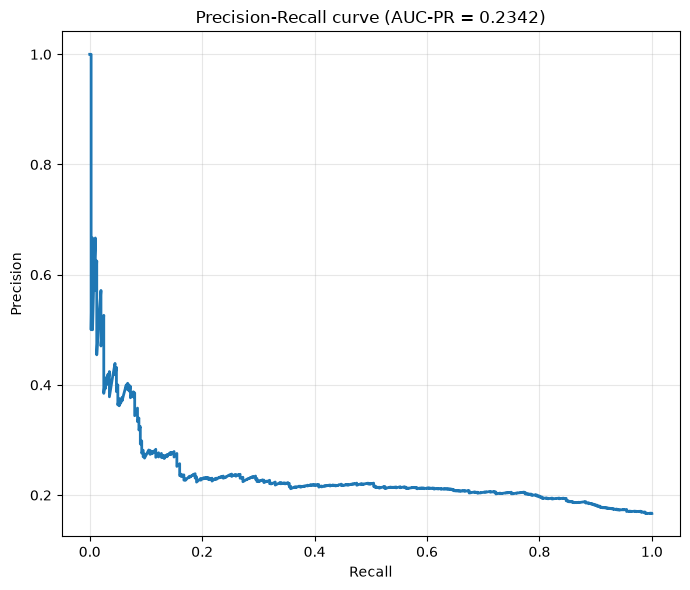

Saved D:\ARGUS\backend\notebooks\precision_recall_curve.png
AUC-PR: 0.2342
Baseline (random) precision = cheater rate = 0.1667


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc as sk_auc
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(
    results["true_label"], results["ensemble_score"]
)
pr_auc = sk_auc(recalls, precisions)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls, precisions, linewidth=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (AUC-PR = {pr_auc:.4f})")
ax.grid(alpha=0.3)
fig.tight_layout()

pr_path = Path("precision_recall_curve.png")
fig.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {pr_path.resolve()}")
print(f"AUC-PR: {pr_auc:.4f}")
print(f"Baseline (random) precision = cheater rate = {results['true_label'].mean():.4f}")

## Recommend thresholds: F1-optimal + higher-precision alternative

In [5]:
best_f1_row = max(sweep_results, key=lambda r: r["f1"])

print("=== F1-optimal threshold ===")
print(f"threshold={best_f1_row['threshold']:.2f}  precision={best_f1_row['precision']:.4f}  "
      f"recall={best_f1_row['recall']:.4f}  f1={best_f1_row['f1']:.4f}  "
      f"n_flagged={best_f1_row['n_flagged']}  false_positives={best_f1_row['false_positives']}")

high_precision_candidates = [r for r in sweep_results if r["precision"] >= 0.40]

print()
print("=== Higher-precision alternative (precision >= 0.40) ===")
if high_precision_candidates:
    # Among candidates clearing the precision bar, prefer the one with
    # the highest recall (least sensitivity sacrificed for that bar).
    best_precision_row = max(high_precision_candidates, key=lambda r: r["recall"])
    print(f"threshold={best_precision_row['threshold']:.2f}  "
          f"precision={best_precision_row['precision']:.4f}  "
          f"recall={best_precision_row['recall']:.4f}  f1={best_precision_row['f1']:.4f}  "
          f"n_flagged={best_precision_row['n_flagged']}  "
          f"false_positives={best_precision_row['false_positives']}")
else:
    # The coarse 0.05-step sweep tops out at precision 0.3784 (threshold
    # 0.90) -- it never crosses 0.40. Search the FINE-grained
    # precision_recall_curve (Cell 4, every unique score as a threshold)
    # instead of giving up at the sweep's resolution.
    print("No threshold in the 0.10-0.90 / 0.05-step sweep reaches precision >= 0.40 "
          "(it tops out at 0.3784 at threshold=0.90). Searching the finer-grained "
          "precision_recall_curve thresholds instead.")

    fine_mask = precisions[:-1] >= 0.40
    if fine_mask.any():
        fine_idx = int(np.argmax(fine_mask))  # first (lowest) threshold clearing the bar
        fine_threshold = float(pr_thresholds[fine_idx])
        pred_fine = (results["ensemble_score"].values >= fine_threshold).astype(int)
        best_precision_row = {
            "threshold": fine_threshold,
            "precision": precision_score(results["true_label"], pred_fine, zero_division=0),
            "recall": recall_score(results["true_label"], pred_fine, zero_division=0),
            "f1": f1_score(results["true_label"], pred_fine, zero_division=0),
            "n_flagged": int(pred_fine.sum()),
            "false_positives": int(((pred_fine == 1) & (results["true_label"] == 0)).sum()),
        }
        print(f"threshold={best_precision_row['threshold']:.4f}  "
              f"precision={best_precision_row['precision']:.4f}  "
              f"recall={best_precision_row['recall']:.4f}  f1={best_precision_row['f1']:.4f}  "
              f"n_flagged={best_precision_row['n_flagged']}  "
              f"false_positives={best_precision_row['false_positives']}")
    else:
        print("Precision >= 0.40 is not reachable at ANY threshold on this test set -- "
              "reporting the highest-precision threshold available instead.")
        best_precision_row = max(sweep_results, key=lambda r: r["precision"])
        print(f"threshold={best_precision_row['threshold']:.2f}  "
              f"precision={best_precision_row['precision']:.4f}  "
              f"recall={best_precision_row['recall']:.4f}  f1={best_precision_row['f1']:.4f}  "
              f"n_flagged={best_precision_row['n_flagged']}  "
              f"false_positives={best_precision_row['false_positives']}")

recall_cost = best_f1_row["recall"] - best_precision_row["recall"]
print(f"\nTradeoff vs F1-optimal: precision "
      f"{best_precision_row['precision'] - best_f1_row['precision']:+.4f}, "
      f"recall {-recall_cost:+.4f} "
      f"(costs {recall_cost:.4f} recall to gain that precision).")

=== F1-optimal threshold ===
threshold=0.50  precision=0.2090  recall=0.6475  f1=0.3160  n_flagged=1239  false_positives=980

=== Higher-precision alternative (precision >= 0.40) ===
No threshold in the 0.10-0.90 / 0.05-step sweep reaches precision >= 0.40 (it tops out at 0.3784 at threshold=0.90). Searching the finer-grained precision_recall_curve thresholds instead.
threshold=0.8275  precision=0.4000  recall=0.0700  f1=0.1191  n_flagged=70  false_positives=42

Tradeoff vs F1-optimal: precision +0.1910, recall -0.5775 (costs 0.5775 recall to gain that precision).


## Save FLAG_THRESHOLD to scoring_config.json

In [6]:
import json

scoring_config_path = BACKEND_DIR / "trained_models" / "scoring_config.json"
with open(scoring_config_path, encoding="utf-8") as f:
    scoring_config = json.load(f)

old_default_note = 0.75  # Doc 01's previously documented default (no longer used if it differs)

scoring_config["flag_threshold"] = best_f1_row["threshold"]
scoring_config["flag_threshold_precision"] = best_f1_row["precision"]
scoring_config["flag_threshold_recall"] = best_f1_row["recall"]
scoring_config["flag_threshold_f1"] = best_f1_row["f1"]
scoring_config["flag_threshold_high_precision_alt"] = best_precision_row["threshold"]

with open(scoring_config_path, "w", encoding="utf-8") as f:
    json.dump(scoring_config, f, indent=2)

print(f"Saved flag_threshold={best_f1_row['threshold']:.2f} to {scoring_config_path}")
if abs(best_f1_row["threshold"] - old_default_note) > 1e-9:
    print(f"NOTE: this differs from Doc 01's previously documented default of "
          f"{old_default_note:.2f} -- the data-derived F1-optimal value is used instead.")
else:
    print(f"This matches Doc 01's previously documented default of {old_default_note:.2f}.")

print()
print("Final scoring_config.json contents:")
print(json.dumps(scoring_config, indent=2))

Saved flag_threshold=0.50 to D:\ARGUS\backend\trained_models\scoring_config.json
NOTE: this differs from Doc 01's previously documented default of 0.75 -- the data-derived F1-optimal value is used instead.

Final scoring_config.json contents:
{
  "if_score_p1": -0.12177912083087014,
  "if_score_p99": 0.08299678789178934,
  "ae_score_p1": 0.015224658520892262,
  "ae_score_p99": 1.8832051980495212,
  "if_score_median": -0.06934903217390165,
  "if_score_scale": 0.05119397718066487,
  "ae_score_median": 0.1099381297826767,
  "ae_score_scale": 0.4669951348821573,
  "ensemble_weight_if": 0.3,
  "flag_threshold": 0.5,
  "flag_threshold_precision": 0.20903954802259886,
  "flag_threshold_recall": 0.6475,
  "flag_threshold_f1": 0.3160463697376449,
  "flag_threshold_high_precision_alt": 0.8274662989865251
}
